## Read file and save it to a df

In [8]:
import pandas as pd

df = pd.read_csv('cleaned_customer_sales_data.csv')
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email,Phone_Number,Country
0,CUST4371,Paul Wilson,male,52,kolkata,2025-06-26,2025-05-17,26944.0,1.0,peckvictoria@example.com,2131107701,india
1,CUST5957,Jason Thomas,male,51,kolkata,2021-02-17,2025-07-22,44152.0,2.0,owensanthony@example.com,1080761560,india
2,CUST3754,Brittney Martinez,female,62,hyderabad,2023-11-05,2024-12-08,31745.0,2.0,tara39@example.org,8981006345,india
3,CUST2934,Brenda Pierce,female,40,hyderabad,2022-03-13,2025-10-02,39674.0,1.0,berrynancy@example.org,8228064204,india
4,CUST5683,Matthew Carroll,female,41,chennai,2024-04-05,2024-12-15,24268.0,8.0,denise84@example.org,2665569480,india
...,...,...,...,...,...,...,...,...,...,...,...,...
8984,CUST6352,Isaiah Terry,female,26,kolkata,2023-03-04,2025-06-30,43655.0,6.0,lopezleonard@example.net,7694723210,india
8985,CUST6146,Cody Thompson,female,40,kolkata,2024-08-21,2024-10-26,35101.0,1.0,mitchellrivera@example.net,6380823112,india
8986,CUST10767,Robert Lewis,female,35,delhi,2020-12-08,2025-01-25,24167.0,9.0,barrycrane@example.net,5004696571,india
8987,CUST6315,Joshua Martinez,male,25,hyderabad,2022-02-15,2025-01-11,43832.0,2.0,kelli74@example.org,8147428496,india


In [7]:
df.dtypes

Customer_ID            object
Name                   object
Gender                 object
Age                     int64
City                   object
Signup_Date            object
Last_Purchase_Date     object
Purchase_Amount       float64
Feedback_Score        float64
Email                  object
Phone_Number            int64
Country                object
dtype: object

## Check datatype of each column

In [11]:
#changing date columns to datetime
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Last_Purchase_Date'] = pd.to_datetime(df['Last_Purchase_Date'])

## Univariate Analysis

In [99]:
numerical_cols

['Age', 'Purchase_Amount', 'Feedback_Score', 'Previous_Purchases']

In [21]:
#summary statistics for numerical columns
# df.describe()
# df.describe().T
numerical_cols = ['Age', 'Purchase_Amount', 'Feedback_Score']

summary = df[numerical_cols].describe().T
summary['median'] = df[numerical_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df[numerical_cols].skew()
print("Numeric Summary Statistics:/n")
summary

Numeric Summary Statistics:/n


,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,8989.0,43.418845,14.205506,3.0,32.0,43.0,55.0,69.0,43.0,23.0,0.007311
Purchase_Amount,8989.0,24654.581266,13622.638940,-500.0,13831.0,24268.0,35660.0,49992.0,24268.0,21829.0,0.050347
Feedback_Score,8989.0,5.138280,2.909729,1.0,2.0,5.0,8.0,10.0,5.0,6.0,0.188718


### histogram, bloxplot, density plot for numerical columns

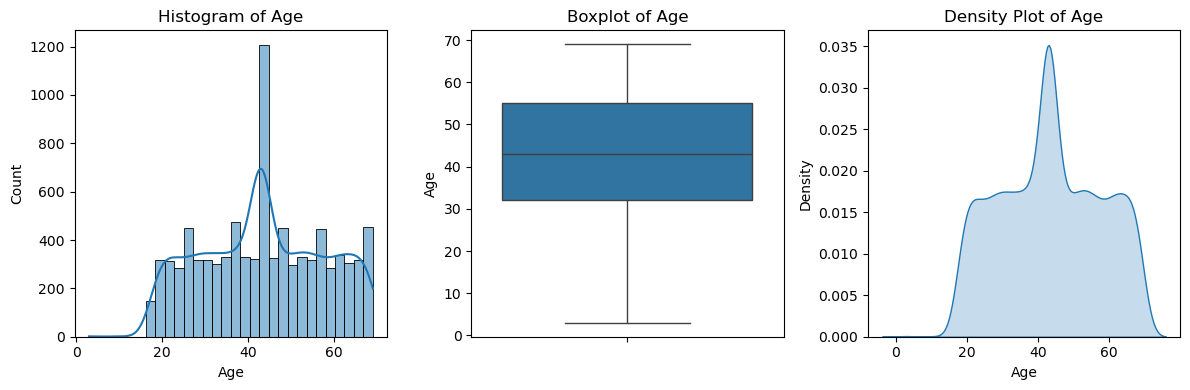

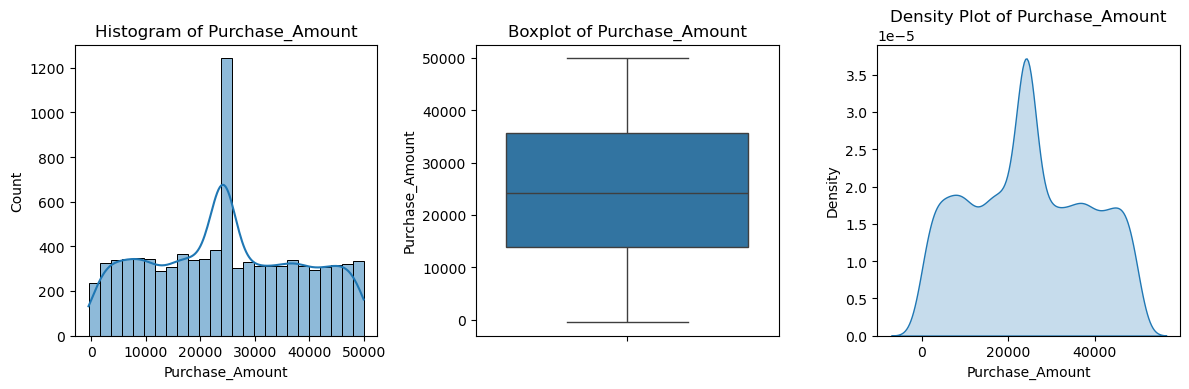

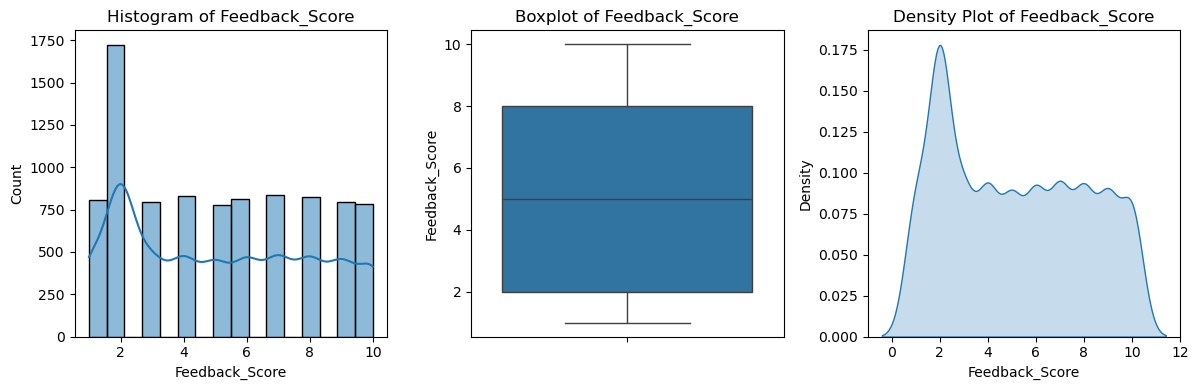

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram, boxplot, and density plot for numerical columns
for col in numerical_cols:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    # Density plot
    plt.subplot(1, 3, 3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()

### Frequency counts for Categorical columns


Frequency counts for Gender:

Gender
male      4958
female    4031
Name: count, dtype: int64


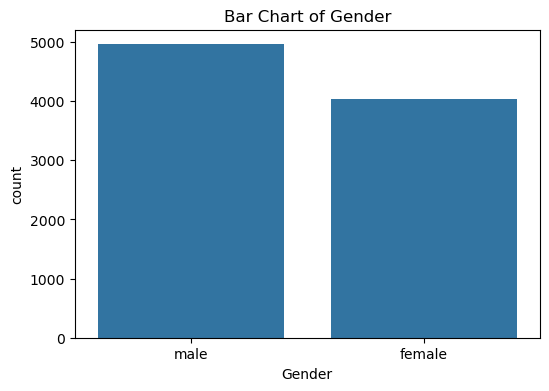


Frequency counts for City:

City
kolkata      2255
mumbai       1358
chennai      1354
delhi        1350
hyderabad    1337
bangalore    1335
Name: count, dtype: int64


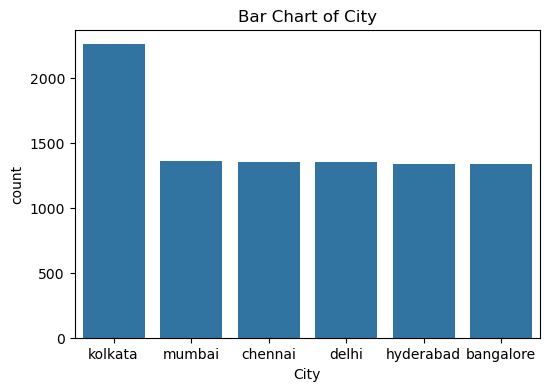

In [34]:
cat_cols = ['Gender', 'City']

for col in cat_cols:
    print(f"\nFrequency counts for {col}:\n")
    print(df[col].value_counts())

    plt.figure(figsize=(6, 4))

    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index
    )

    plt.title(f'Bar Chart of {col}')
    plt.show()  

### Analysis by Month and Year data


 Date Range for Signup_Date: 2020-10-08 00:00:00 to 2025-10-08 00:00:00

Time Span: 1826 days

 Date Range for Last_Purchase_Date: 2024-10-08 00:00:00 to 2025-10-08 00:00:00

Time Span: 365 days


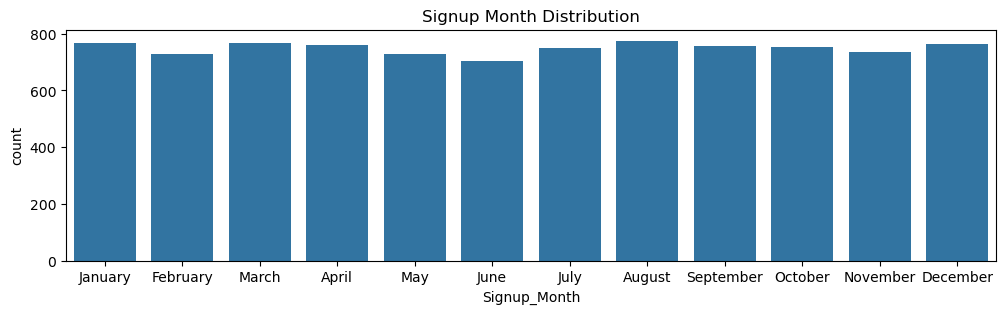

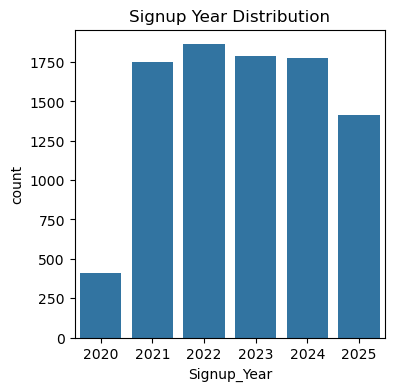

In [40]:
date_cols = ['Signup_Date', 'Last_Purchase_Date']

for col in date_cols:
    print(f"\n Date Range for {col}: {df[col].min()} to {df[col].max()}")
    print(f"\nTime Span: {(df[col].max() - df[col].min()).days} days")

#month distribution
plt.figure(figsize = (12,3))
df['Signup_Month'] = df['Signup_Date'].dt.month_name()
sns.countplot(
    x='Signup_Month',
    data=df,
    order=[
        'January', 'February', 'March', 'April','May', 'June', 'July', 'August','September', 'October', 'November', 'December'])

plt.title('Signup Month Distribution')
plt.show()


# Year Distribution
plt.figure(figsize = (4,4))
df['Signup_Year'] = df['Signup_Date'].dt.year
sns.countplot(x='Signup_Year', data = df)

plt.title('Signup Year Distribution')
plt.show()

### Time Granularity analysis

In [41]:
def time_granularity(series):
    diffs = series.sort_values().diff().dropna().dt.days
    return diffs.describe()

In [42]:
time_granularity(df['Last_Purchase_Date'])

count    8086.000000
mean        0.045140
std         0.207623
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Last_Purchase_Date, dtype: float64

In [45]:
df['Last_Purchase_Date'].sort_values()

1617   2024-10-08
928    2024-10-08
6493   2024-10-08
373    2024-10-08
1596   2024-10-08
          ...    
8914          NaT
8938          NaT
8948          NaT
8951          NaT
8978          NaT
Name: Last_Purchase_Date, Length: 8989, dtype: datetime64[ns]

In [47]:
df['Last_Purchase_Date'].sort_values().diff()

1617      NaT
928    0 days
6493   0 days
373    0 days
1596   0 days
        ...  
8914      NaT
8938      NaT
8948      NaT
8951      NaT
8978      NaT
Name: Last_Purchase_Date, Length: 8989, dtype: timedelta64[ns]

In [49]:
df['Last_Purchase_Date'].sort_values().diff().value_counts()

Last_Purchase_Date
0 days    7721
1 days     365
Name: count, dtype: int64

In [51]:
df['Signup_Date'].sort_values().diff().value_counts()

Signup_Date
0 days    7174
1 days    1803
2 days      10
3 days       1
Name: count, dtype: int64

<Axes: xlabel='Last_Purchase_Date'>

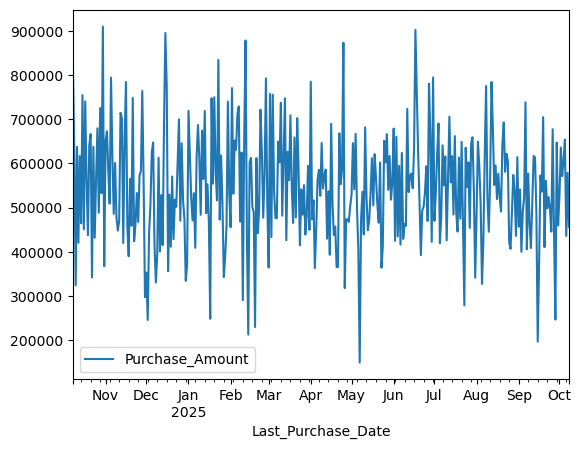

In [53]:
df.groupby('Last_Purchase_Date')[['Purchase_Amount']].sum().plot()

### seasonal decomposition

C:\Users\Sailaja\AppData\Local\Temp\ipykernel_11624\4004069096.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  result.plot().show()


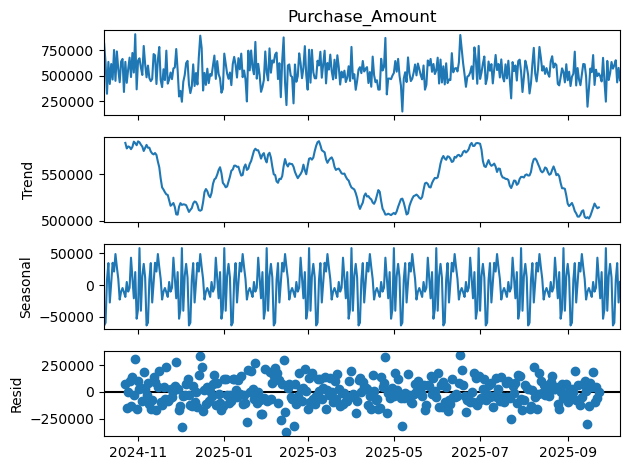

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_daily = df.groupby('Last_Purchase_Date') ['Purchase_Amount'].sum()
result = seasonal_decompose(df_daily, model = 'addictive', period=30)
result.plot().show()

### Heatmap analysis

In [78]:
heatmap_data = df.pivot_table(
    index="day",
    columns="month",
    values="Purchase_Amount",
    aggfunc="mean"
)
heatmap_data

month,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0
day,,,,,,,,,,,,
1.0,27659.423077,23982.578947,21436.705882,26166.433333,25182.571429,26115.615385,27651.176471,22087.954545,21750.333333,25070.285714,21031.516129,22055.875000
2.0,26974.478261,32107.166667,25255.733333,23668.000000,26918.208333,21238.900000,24191.818182,25967.800000,27060.600000,31804.650000,28032.375000,22319.727273
3.0,24903.952381,27971.105263,22799.947368,24590.523810,23538.173913,22778.689655,25919.083333,27006.136364,23529.588235,28558.900000,22391.884615,22116.850000
4.0,27715.176471,26092.080000,31494.458333,19105.315789,25663.230769,24160.888889,21579.062500,28244.055556,28910.176471,26294.347826,25450.500000,26693.736842
5.0,25368.666667,27430.043478,23280.608696,26540.529412,26392.052632,23777.000000,24672.235294,23361.214286,24844.714286,24222.666667,27391.034483,26069.916667
6.0,19475.714286,25374.785714,23840.850000,24472.347826,20165.350000,23119.888889,23985.100000,21317.300000,23073.875000,25640.588235,25646.625000,29428.454545
7.0,32442.157895,28042.192308,27988.470588,23419.200000,14909.500000,24953.120000,26714.083333,27986.500000,22539.555556,26300.045455,21124.652174,24439.470588
8.0,29877.000000,20362.739130,27057.916667,30989.470588,21503.090909,25240.470588,28969.368421,26740.379310,25091.086957,25977.428571,27318.818182,22022.333333
9.0,24377.400000,23135.814815,21514.035714,25856.000000,21430.840000,25755.722222,25662.666667,30726.000000,33051.928571,24102.884615,21733.181818,21874.666667


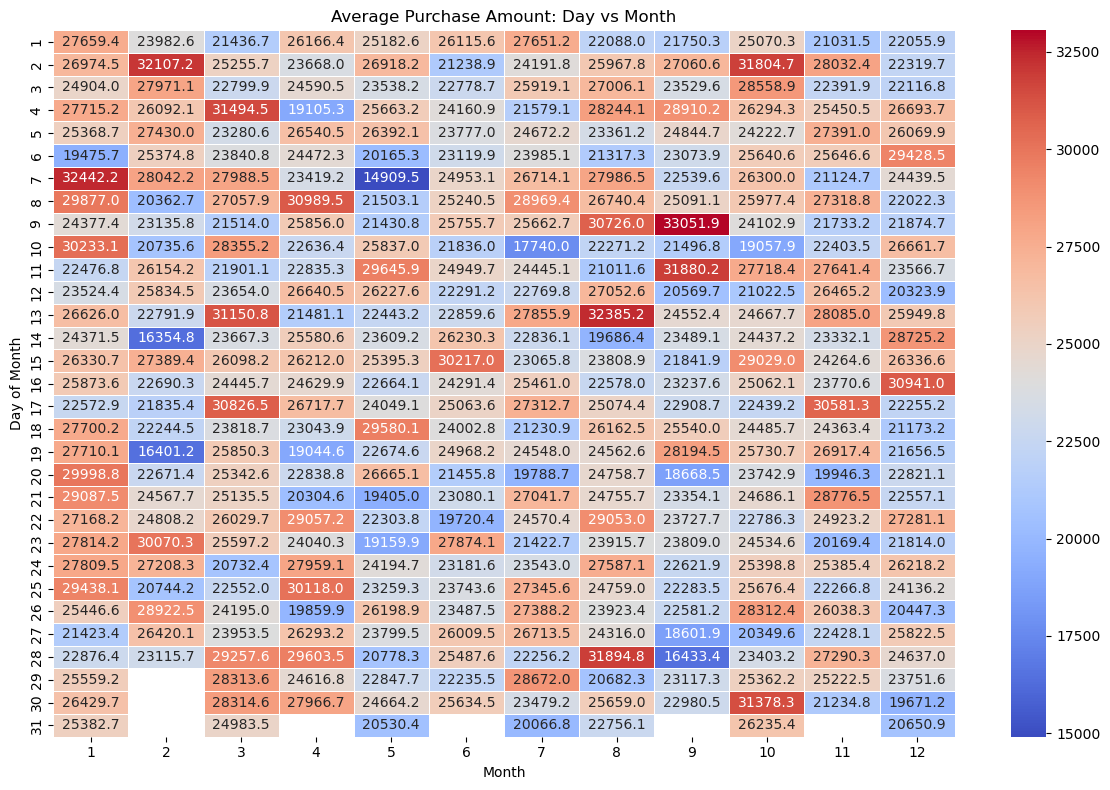

In [79]:
# Extract day and month
df['day'] = df['Last_Purchase_Date'].dt.day.astype('Int64')
df['month'] = df['Last_Purchase_Date'].dt.month.astype('Int64')

# Create pivot table
heatmap_data = df.pivot_table(
    index='day',
    columns='month',
    values='Purchase_Amount',
    aggfunc='mean'
)

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data,annot=True,cmap='coolwarm',fmt='.1f',linewidths=0.5)

plt.xlabel('Month')
plt.ylabel('Day of Month')
plt.title('Average Purchase Amount: Day vs Month')

plt.tight_layout()
plt.show()

In [115]:
numerical_cols
cat_cols

['Age', 'Purchase_Amount', 'Feedback_Score']

## Bivariate Analysis

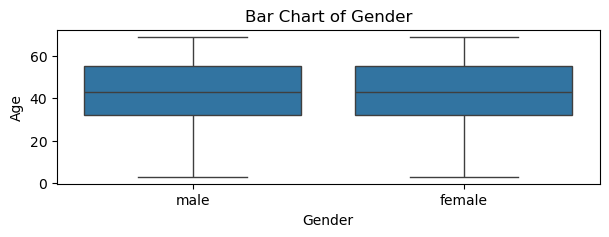


 Group Mean and Median of Age by Gender
         mean  median  count
Gender                      
female  43.45    43.0   4031
male    43.40    43.0   4958


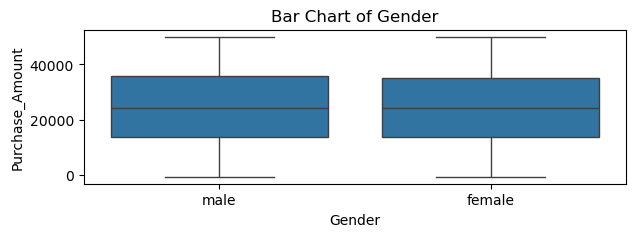


 Group Mean and Median of Purchase_Amount by Gender
            mean   median  count
Gender                          
female  24430.36  24268.0   4031
male    24836.88  24268.0   4958


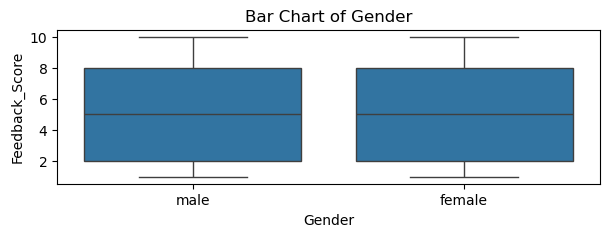


 Group Mean and Median of Feedback_Score by Gender
        mean  median  count
Gender                     
female  5.13     5.0   4031
male    5.15     5.0   4958


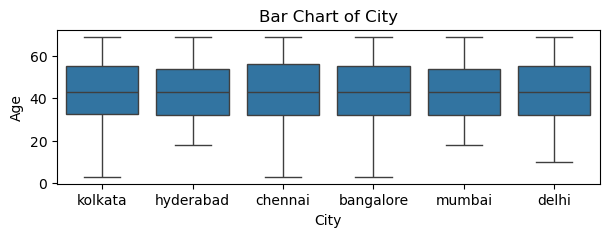


 Group Mean and Median of Age by City
            mean  median  count
City                           
bangalore  43.31    43.0   1335
chennai    43.88    43.0   1354
delhi      43.43    43.0   1350
hyderabad  43.65    43.0   1337
kolkata    43.45    43.0   2255
mumbai     42.78    43.0   1358


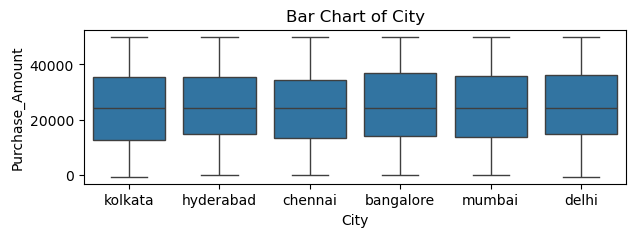


 Group Mean and Median of Purchase_Amount by City
               mean   median  count
City                               
bangalore  25189.22  24268.0   1335
chennai    23969.14  24268.0   1354
delhi      25101.27  24268.0   1350
hyderabad  24790.83  24268.0   1337
kolkata    24372.16  24268.0   2255
mumbai     24703.19  24268.0   1358


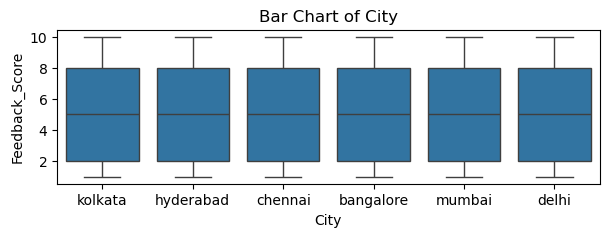


 Group Mean and Median of Feedback_Score by City
           mean  median  count
City                          
bangalore  5.26     5.0   1335
chennai    5.08     5.0   1354
delhi      5.11     5.0   1350
hyderabad  5.21     5.0   1337
kolkata    5.08     5.0   2255
mumbai     5.14     5.0   1358


In [120]:
cat_cols = ['Gender', 'City']

for col in cat_cols:
    for num in numerical_cols:
        plt.figure(figsize=(7,2))
        sns.boxplot(x=col, y=num, data=df)
        plt.title(f'Bar Chart of {col}')
        plt.show()  

        print(f"\n Group Mean and Median of {num} by {col}")
        print(df.groupby(col)[num].agg(['mean', 'median', 'count']).round(2))

## Multivariate Analysis

### Interaction Plot

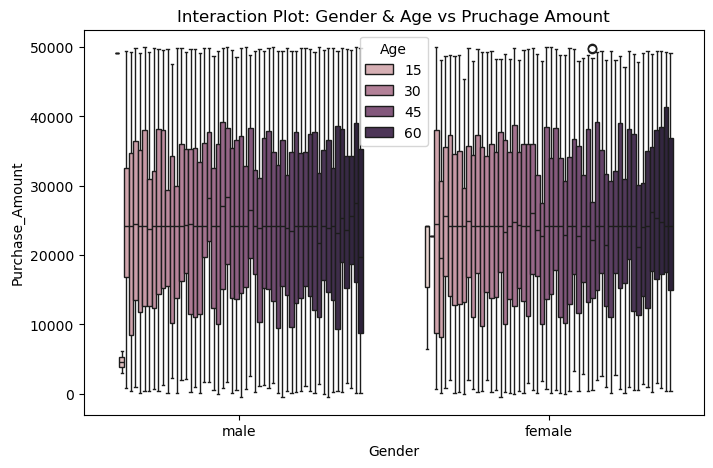

In [81]:
# Age, Gender -> Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(
    data= df,
    x='Gender',
    y='Purchase_Amount',
    hue='Age',
    dodge=True
)
plt.title('Interaction Plot: Gender & Age vs Pruchage Amount')
plt.show()

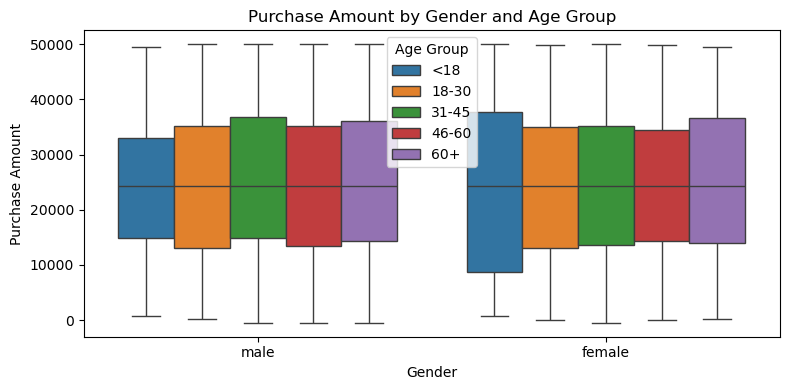

In [85]:
#create age groups
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '60+']
)

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x='Gender',
    y='Purchase_Amount',
    hue='Age_Group'
)

plt.title('Purchase Amount by Gender and Age Group')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.legend(title='Age Group')
plt.tight_layout()
plt.show()

### Interaction plot with different parameter

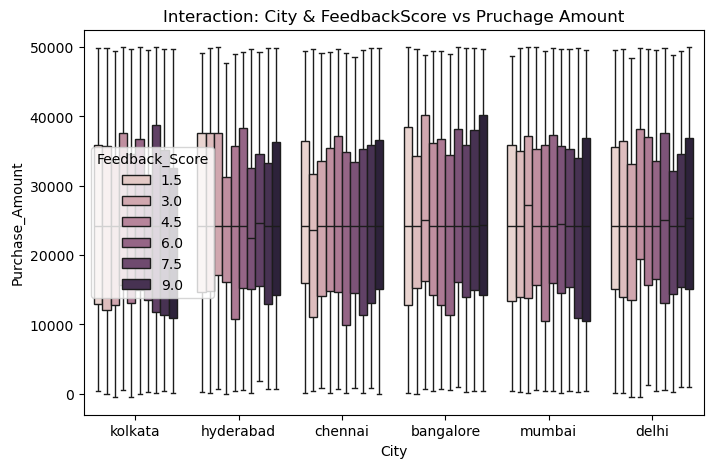

In [90]:
# City, FeedbackScore -> Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(
    data= df,
    x='City',
    y='Purchase_Amount',
    hue='Feedback_Score'
)
plt.title('Interaction: City & FeedbackScore vs Pruchage Amount')
plt.show()

### Principal Component Analysis (PCA)/ Clustering

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

numerical_cols = ['Age', 'Purchase_Amount', 'Feedback_Score']
X = df[numerical_cols]

#Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components to DataFrame
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
          
print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.33732738 0.33268221]


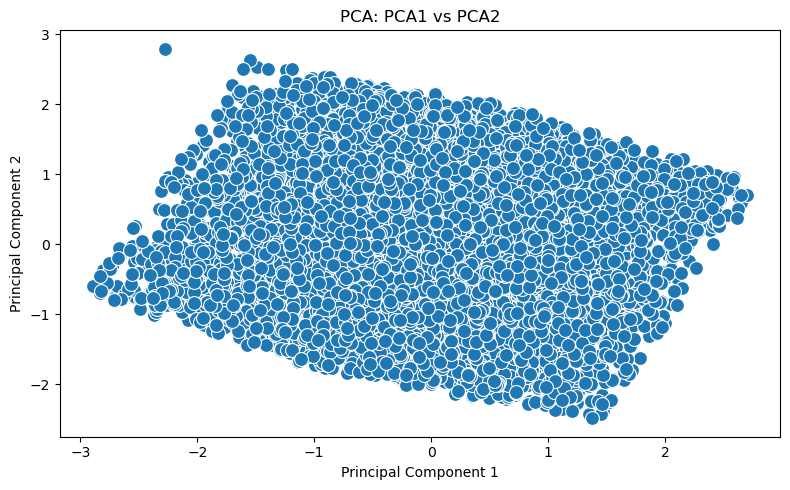

In [105]:
# Plot PCA1, PCA2 graph

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    data=df,
    s=100
)
plt.title('PCA: PCA1 vs PCA2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

### KMeans Clustering

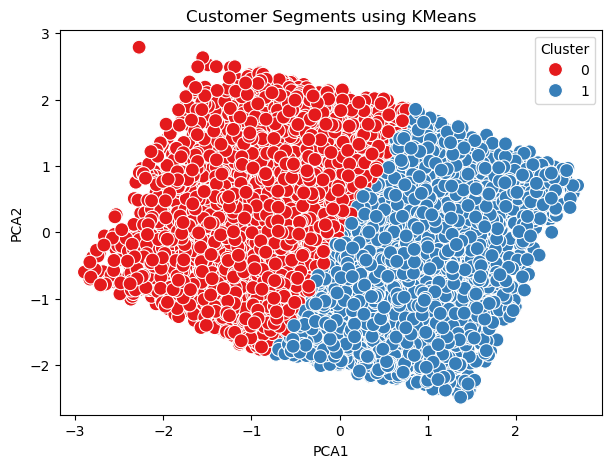

In [109]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)
plt.title('Customer Segments using KMeans')
plt.show()

In [110]:
df['Cluster'].value_counts()

Cluster
0    4638
1    4351
Name: count, dtype: int64

In [113]:
print(df.groupby('Cluster')[numerical_cols].mean())

               Age  Purchase_Amount  Feedback_Score
Cluster                                            
0        35.872790     24738.410737        6.858560
1        51.462652     24565.222248        3.304528
